In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sns.set_theme(style="whitegrid")

In [16]:
path = "../results/autom/"

dfs = []
for csv_path in glob.glob(path + "*/output_autom_new.csv"):
    df = pd.read_csv(csv_path)
    dfs += [df]

df = pd.concat(dfs)

df = df.drop("count_mu", axis=1)
df = df.drop("count_no_mu", axis=1)

df_autom = df.melt(["n", "k", "id"])
df_autom['mu'] = df_autom['variable'].replace({'time_mu': 'yes', 'time_no_mu': 'no'})
df_autom = df_autom.drop("variable", axis=1)
print(df_autom.describe())



                 n            k           id        value
count  1900.000000  1900.000000  1900.000000  1900.000000
mean     45.263158    28.421053    47.342105    51.883935
std      35.456612    34.231679    29.586652   149.623286
min      10.000000     0.000000     0.000000     0.001040
25%      10.000000     0.000000    20.000000     0.033616
50%      50.000000    10.000000    47.000000     1.301347
75%      50.000000    50.000000    73.000000    33.644096
max     100.000000   100.000000    99.000000  1596.186426


/mnt/scratch_dir/jansser/conda/envs/remie-base/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/mnt/scratch_dir/jansser/conda/envs/remie-base/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/mnt/scratch_dir/jansser/conda/envs/remie-base/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/mnt/scratch_dir/jansser/conda/envs/remie-base

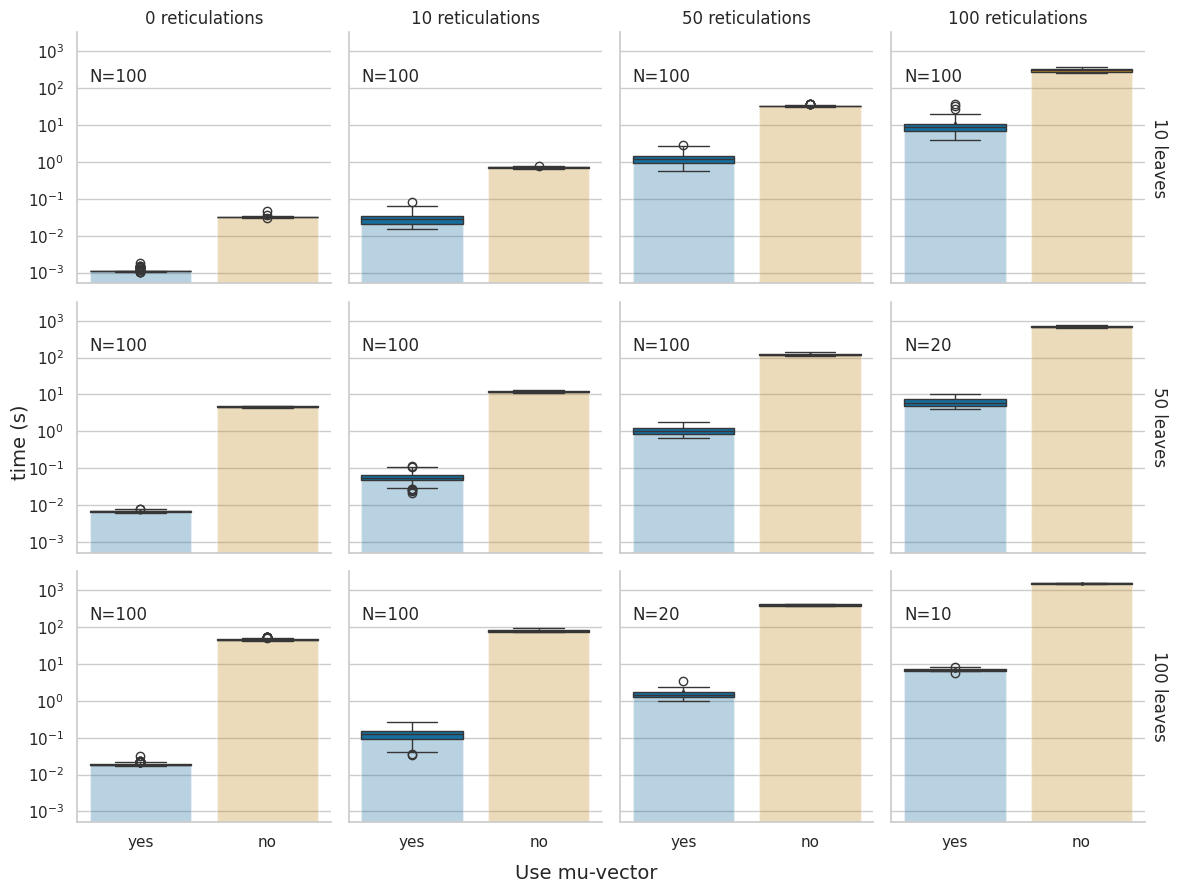

In [34]:
g = sns.FacetGrid(df_autom, col="k", row="n", margin_titles=True)
g.map(sns.barplot, "mu", "value", order=["yes", "no"], palette='colorblind', alpha=0.3).set(yscale = 'log')
g.map(sns.boxplot, "mu", "value", order=["yes", "no"], palette='colorblind').set(yscale = 'log')
g.set_axis_labels("", "")
g.figure.supxlabel("Use mu-vector", fontsize=14)
g.figure.supylabel("time (s)", fontsize=14)
g.set_titles(row_template='{row_name} leaves', col_template='{col_name} reticulations')
g.tick_params()

# set datapoint count in each subfig
for ax, (idx, data) in zip(g.axes.flat, g.facet_data()):
    # print(idx, data)
    n_points = len(data.index)
    ax.text(-0.4, 150.0, f'N={n_points//2}')


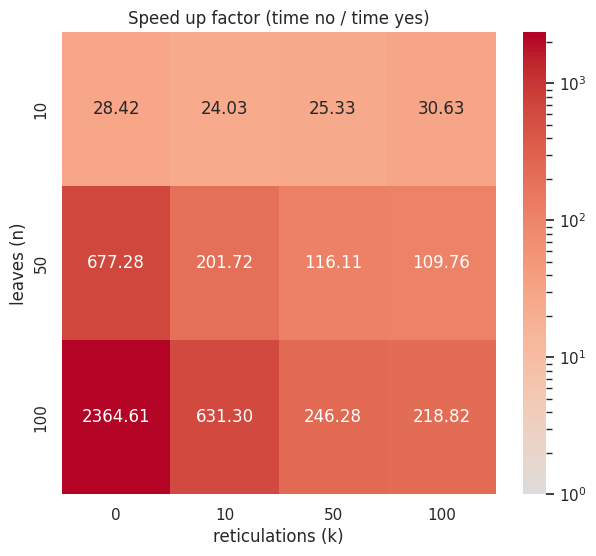

In [32]:
pivoted = df_autom.groupby(['n', 'k', 'mu'])['value'].mean().reset_index()

diff = (
    pivoted[pivoted['mu'] == 'no']
    .set_index(['n','k'])['value']
    / pivoted[pivoted['mu'] == 'yes']
    .set_index(['n','k'])['value']
).unstack()
plt.figure(figsize=(7,6))
sns.heatmap(diff, annot=True, fmt=".2f", cmap='coolwarm', center=1, norm=mcolors.LogNorm(vmin=1),
)
plt.title('Speed up factor (time no / time yes)')
plt.xlabel('reticulations (k)')
plt.ylabel('leaves (n)')
plt.show()